# Opioid Overdose Analysis - Cleaned Version



In [ ]:

from pathlib import Path
from typing import Dict, List, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.impute import KNNImputer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import GroupKFold, cross_val_score, train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline

sns.set_style("whitegrid")


# -----------------------------
# Configuration
# -----------------------------
from pathlib import Path

DATA_DIR = Path("/content/")
RANDOM_STATE = 42
FUTURE_YEARS = [2024, 2025, 2026, 2027]


# -----------------------------
# Loading
# -----------------------------
def load_data(data_dir: Path = DATA_DIR) -> Dict[str, pd.DataFrame]:
    """Load all project datasets."""
    demographic_df = pd.read_excel(
        data_dir / "Demographic_Data 2020-2024.xlsx",
        header=0,
        skiprows=[0],
    )
    census_df = pd.read_excel(
        data_dir / "DECENNIALCDP1.xlsx",
        header=0,
        skiprows=[0],
    )
    overdose_df = pd.read_excel(
        data_dir / "SUDORS-Fatal-Overdose-Data.xlsx",
        sheet_name="Data",
    )
    naloxone_df = pd.read_excel(
        data_dir / "State Naloxone Dispensing Rates.xlsx"
    )
    unemployment_df = pd.read_excel(
        data_dir / "US_Unemployment_SeriesReport-202509.xlsx",
        header=0,
        skiprows=11,
    )
    sudors_cols_df = pd.read_excel(data_dir / "SUDORS COLUMNS v3.xlsx")

    return {
        "demographic": demographic_df,
        "census": census_df,
        "overdose": overdose_df,
        "naloxone": naloxone_df,
        "unemployment": unemployment_df,
        "sudors_cols": sudors_cols_df,
    }


# -----------------------------
# Utility helpers
# -----------------------------
def safe_rmse(y_true, y_pred) -> float:
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))


def print_regression_metrics(model_name: str, y_true, y_pred) -> None:
    print(f"\n{model_name}")
    print("-" * len(model_name))
    print(f"MSE : {mean_squared_error(y_true, y_pred):.4f}")
    print(f"RMSE: {safe_rmse(y_true, y_pred):.4f}")
    print(f"R²  : {r2_score(y_true, y_pred):.4f}")


# -----------------------------
# Demographic + census prep
# -----------------------------
def calculate_poverty_population_percentage(
    demographic_df: pd.DataFrame,
    census_df: pd.DataFrame,
) -> pd.DataFrame:
    """
    2020 Poverty-status-vs-total-population check.
    """
    pop_percent = demographic_df.loc[
        demographic_df["Year"] == 2020,
        [
            "Year",
            "Geographic Area Name",
            "Estimate!!Total!!Population for whom poverty status is determined",
        ],
    ].copy()

    merged = pop_percent.merge(
        census_df[["Geographic Area ", " Total"]],
        left_on="Geographic Area Name",
        right_on="Geographic Area ",
        how="left",
    )

    merged["poverty_status_population_pct"] = (
        merged["Estimate!!Total!!Population for whom poverty status is determined"]
        / merged[" Total"]
        * 100
    )
    return merged


# -----------------------------
# Overdose subset prep
# -----------------------------
def build_overdose_subset(
    overdose_df: pd.DataFrame,
    sudors_cols_df: pd.DataFrame,
) -> pd.DataFrame:
    """Keep only requested SUDORS columns, plus required IDs."""
    cols_to_keep = sudors_cols_df.iloc[:, 0].dropna().astype(str).tolist()
    required_cols = ["Jurisdiction", "year"]
    for col in required_cols:
        if col not in cols_to_keep:
            cols_to_keep.append(col)

    existing_cols = [c for c in cols_to_keep if c in overdose_df.columns]
    return overdose_df[existing_cols].copy()


def build_demo_overdose_merge(
    demographic_df: pd.DataFrame,
    overdose_df: pd.DataFrame,
) -> Tuple[pd.DataFrame, List[str], str]:
    """
    Merge demographic and overdose data for EDA and demographic-only modeling.
    """
    demo_cols = [
        c
        for c in demographic_df.columns
        if pd.api.types.is_numeric_dtype(demographic_df[c])
        and (c.startswith("Precent_") or "Median" in c or "median" in c)
    ]

    demosub = demographic_df[
        ["Year", "Geographic Area Name"] + demo_cols
    ].dropna(subset=["Year", "Geographic Area Name"]).copy()

    od_rate_cols = [
        c for c in [
            "Jurisdiction",
            "year",
            "alldrug_rate",
            "opioids_rate",
            "imfs_rate",
            "heroin_rate",
            "rxopioids_rate",
        ] if c in overdose_df.columns
    ]
    od_rate_df = overdose_df[od_rate_cols].copy()

    demo_od = pd.merge(
        demosub,
        od_rate_df,
        left_on=["Geographic Area Name", "Year"],
        right_on=["Jurisdiction", "year"],
        how="inner",
    )

    target_candidates = [
        c for c in ["opioids_rate", "alldrug_rate", "imfs_rate"]
        if c in demo_od.columns
    ]
    primary_target = target_candidates[0] if target_candidates else None

    return demo_od, demo_cols, primary_target


# -----------------------------
# Unemployment reshape
# -----------------------------
def reshape_unemployment(unemployment_df: pd.DataFrame) -> pd.DataFrame:
    """Convert wide monthly unemployment table into long format."""
    month_cols = [
        c for c in unemployment_df.columns
        if c not in ["Year"] and not str(c).startswith("Unnamed")
    ]

    long_df = unemployment_df.melt(
        id_vars="Year",
        value_vars=month_cols,
        var_name="Month",
        value_name="Unemployment Rate",
    ).copy()

    long_df["Date"] = pd.to_datetime(
        long_df["Year"].astype(str) + "-" + long_df["Month"],
        format="%Y-%b",
        errors="coerce",
    )
    long_df = long_df.sort_values("Date").reset_index(drop=True)
    long_df["Differenced Rate"] = long_df["Unemployment Rate"].diff()
    return long_df


# -----------------------------
# Naloxone + overdose modeling prep
# -----------------------------
def build_final_modeling_df(
    naloxone_df: pd.DataFrame,
    overdose_subset_df: pd.DataFrame,
) -> pd.DataFrame:
    """
    Merge naloxone and overdose data on state-year,
    then drop redundant columns used only for identifiers.
    """
    nal = naloxone_df.rename(
        columns={"YEAR": "Year", "STATE_NAME": "State"}
    ).copy()
    od = overdose_subset_df.rename(
        columns={"Jurisdiction": "State", "year": "Year"}
    ).copy()

    merged = pd.merge(nal, od, on=["Year", "State"], how="inner")

    drop_cols = [
        c for c in [
            "STATE_FIPS",
            "State",
            "Naloxone Dispensing Rate (per 100 persons)",
        ] if c in merged.columns
    ]
    cleaned = merged.drop(columns=drop_cols)
    return cleaned


def one_hot_encode_features(
    df: pd.DataFrame,
    id_cols: List[str],
    target_cols: List[str],
) -> Tuple[pd.DataFrame, OneHotEncoder | None, List[str]]:
    """
    One-hot encode object columns while keeping only predictor features.
    """
    predictors = [c for c in df.columns if c not in id_cols + target_cols]
    X = df[predictors].copy()
    categorical_cols = X.select_dtypes(include="object").columns.tolist()

    if categorical_cols:
        encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
        encoded = encoder.fit_transform(X[categorical_cols])
        encoded_df = pd.DataFrame(
            encoded,
            columns=encoder.get_feature_names_out(categorical_cols),
            index=X.index,
        )
        X = pd.concat([X.drop(columns=categorical_cols), encoded_df], axis=1)
    else:
        encoder = None

    return X, encoder, categorical_cols


def train_test_prepare(
    modeling_df: pd.DataFrame,
    X: pd.DataFrame,
    y: pd.Series,
    id_cols: List[str],
    target_name: str,
) -> Tuple[pd.DataFrame, pd.DataFrame, KNNImputer, StandardScaler, List[str]]:
    """
    Split, impute, and scale numeric features.
    """
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=RANDOM_STATE
    )

    numeric_cols = X_train.select_dtypes(include=np.number).columns.tolist()

    # drop numeric columns that are entirely missing in training data
    numeric_cols = [col for col in numeric_cols if not X_train[col].isna().all()]

    imputer = KNNImputer(n_neighbors=5, weights="distance")
    scaler = StandardScaler()

    X_train_imp = pd.DataFrame(
        imputer.fit_transform(X_train[numeric_cols]),
        columns=numeric_cols,
        index=X_train.index,
    )
    X_test_imp = pd.DataFrame(
        imputer.transform(X_test[numeric_cols]),
        columns=numeric_cols,
        index=X_test.index,
    )

    X_train_scaled = pd.DataFrame(
        scaler.fit_transform(X_train_imp),
        columns=numeric_cols,
        index=X_train.index,
    )
    X_test_scaled = pd.DataFrame(
        scaler.transform(X_test_imp),
        columns=numeric_cols,
        index=X_test.index,
    )

    train_df = pd.concat(
        [modeling_df.loc[X_train.index, id_cols], y_train.rename(target_name), X_train_scaled],
        axis=1,
    ).dropna(subset=[target_name])

    test_df = pd.concat(
        [modeling_df.loc[X_test.index, id_cols], y_test.rename(target_name), X_test_scaled],
        axis=1,
    ).dropna(subset=[target_name])

    return train_df, test_df, imputer, scaler, numeric_cols


def evaluate_regressors(
    X_train: pd.DataFrame,
    X_test: pd.DataFrame,
    y_train: pd.Series,
    y_test: pd.Series,
) -> Tuple[pd.DataFrame, Dict[str, object]]:
    """
    Fit linear regression, gradient boosting, and random forest.
    """
    models = {
        "Linear Regression": LinearRegression(),
        "Gradient Boosting": GradientBoostingRegressor(random_state=RANDOM_STATE),
        "Random Forest": RandomForestRegressor(random_state=RANDOM_STATE),
    }

    rows = []
    fitted = {}

    for name, model in models.items():
        model.fit(X_train, y_train)
        preds = model.predict(X_test)
        fitted[name] = model

        rows.append(
            {
                "Model": name,
                "MSE": mean_squared_error(y_test, preds),
                "RMSE": safe_rmse(y_test, preds),
                "R2": r2_score(y_test, preds),
            }
        )

    results = pd.DataFrame(rows).sort_values("R2", ascending=False).reset_index(drop=True)
    return results, fitted


# -----------------------------
# Forecasting
# -----------------------------
def build_future_rows(
    historical_df: pd.DataFrame,
    future_years: List[int] = FUTURE_YEARS,
) -> pd.DataFrame:
    """
    Carrying forward each state's latest observed row and update Year.
    """
    all_states = historical_df["State"].unique()
    future_rows = []

    for state in all_states:
        hist = historical_df.loc[historical_df["State"] == state].sort_values("Year")
        if hist.empty:
            continue

        base = hist.iloc[-1].copy()
        for year in future_years:
            row = base.copy()
            row["Year"] = year
            future_rows.append(row)

    return pd.DataFrame(future_rows).reset_index(drop=True)


def transform_future_features(
    future_df: pd.DataFrame,
    categorical_cols: List[str],
    encoder: OneHotEncoder | None,
    numeric_cols_after_encoding: List[str],
    imputer: KNNImputer,
    scaler: StandardScaler,
) -> pd.DataFrame:
    """Apply the same encoding, imputation, and scaling used in training."""
    Xf = future_df.copy()

    for col in categorical_cols:
        if col not in Xf.columns:
            Xf[col] = np.nan

    if encoder is not None and categorical_cols:
        Xf_cat = encoder.transform(Xf[categorical_cols])
        Xf_cat_df = pd.DataFrame(
            Xf_cat,
            columns=encoder.get_feature_names_out(categorical_cols),
            index=Xf.index,
        )
        Xf_num_df = Xf.drop(columns=categorical_cols)
        Xf_encoded = pd.concat([Xf_num_df, Xf_cat_df], axis=1)
    else:
        Xf_encoded = Xf.copy()

    Xf_encoded = Xf_encoded.select_dtypes(include=[np.number])
    Xf_aligned = Xf_encoded.reindex(columns=numeric_cols_after_encoding, fill_value=np.nan)

    Xf_imp = pd.DataFrame(
        imputer.transform(Xf_aligned),
        columns=numeric_cols_after_encoding,
        index=Xf_aligned.index,
    )
    Xf_scaled = pd.DataFrame(
        scaler.transform(Xf_imp),
        columns=numeric_cols_after_encoding,
        index=Xf_imp.index,
    )
    return Xf_scaled


def build_prediction_results(
    future_df: pd.DataFrame,
    overdose_model,
    naloxone_model,
    Xf_scaled: pd.DataFrame,
) -> pd.DataFrame:
    """Create future prediction table."""
    results = future_df[["State", "Year", "STATE_ABBREV"]].copy()
    results["Predicted_Opioid_Overdose_Rate"] = overdose_model.predict(Xf_scaled)
    results["Predicted_Naloxone_Dispensing_Rate"] = naloxone_model.predict(Xf_scaled)
    return results


# -----------------------------
# Clustering and risk index
# -----------------------------
def add_clusters(prediction_results: pd.DataFrame) -> pd.DataFrame:
    """Cluster overdose and naloxone projections into low/medium/high groups."""
    out = prediction_results.copy()

    overdose_km = KMeans(n_clusters=3, random_state=RANDOM_STATE, n_init=10)
    naloxone_km = KMeans(n_clusters=3, random_state=RANDOM_STATE, n_init=10)

    out["Overdose_Cluster_Code"] = overdose_km.fit_predict(
        out[["Predicted_Opioid_Overdose_Rate"]]
    )
    out["Dispensing_Cluster_Code"] = naloxone_km.fit_predict(
        out[["Predicted_Naloxone_Dispensing_Rate"]]
    )

    # Order clusters from low -> high based on cluster centers.
    overdose_order = np.argsort(overdose_km.cluster_centers_.ravel())
    naloxone_order = np.argsort(naloxone_km.cluster_centers_.ravel())

    overdose_map = {cluster: label for cluster, label in zip(overdose_order, ["Low", "Medium", "High"])}
    naloxone_map = {cluster: label for cluster, label in zip(naloxone_order, ["Low", "Medium", "High"])}

    out["Overdose_Cluster"] = out["Overdose_Cluster_Code"].map(overdose_map)
    out["Dispensing_Cluster"] = out["Dispensing_Cluster_Code"].map(naloxone_map)
    return out


def add_risk_index(prediction_results: pd.DataFrame, target_year: int = 2027) -> pd.DataFrame:
    """
    Build the continuous risk index from projected overdose and naloxone rates.
    Higher overdose and lower naloxone imply higher risk.
    """
    out = prediction_results.copy()
    df = out.loc[out["Year"] == target_year].copy()

    def zscore(series: pd.Series) -> pd.Series:
        s = series.astype(float)
        return (s - s.mean()) / (s.std(ddof=0) if s.std(ddof=0) > 0 else 1.0)

    df["overdose_z"] = zscore(df["Predicted_Opioid_Overdose_Rate"])
    df["naloxone_z"] = zscore(df["Predicted_Naloxone_Dispensing_Rate"])
    df["risk_index"] = df["overdose_z"] - df["naloxone_z"]
    return df.sort_values("risk_index", ascending=False).reset_index(drop=True)


# -----------------------------
# Demographic-only modeling
# -----------------------------
def demographic_only_modeling(
    demo_od: pd.DataFrame,
    demo_cols: List[str],
    primary_target: str,
    use_year: bool = False,
) -> pd.DataFrame:
    """
    Demographic-only comparison using Linear Regression, Random Forest, and Gradient Boosting.
    """
    X_cols = demo_cols + (["Year"] if use_year and "Year" in demo_od.columns else [])
    X = demo_od[X_cols].copy()
    y = demo_od[primary_target].astype(float).copy()
    groups = demo_od["Geographic Area Name"].astype(str)

    mask = X.notna().all(axis=1) & y.notna()
    X = X.loc[mask]
    y = y.loc[mask]
    groups = groups.loc[mask]

    X_train, X_test, y_train, y_test, g_train, g_test = train_test_split(
        X, y, groups, test_size=0.2, random_state=RANDOM_STATE
    )

    models = {
        "Linear": Pipeline(
            [("scaler", StandardScaler()), ("reg", LinearRegression())]
        ),
        "RandomForest": RandomForestRegressor(
            n_estimators=600,
            max_depth=None,
            min_samples_leaf=2,
            random_state=RANDOM_STATE,
            n_jobs=-1,
        ),
        "GradientBoosting": GradientBoostingRegressor(random_state=RANDOM_STATE),
    }

    gkf = GroupKFold(n_splits=5)
    rows = []

    for name, model in models.items():
        cv_scores = cross_val_score(
            model,
            X,
            y,
            groups=groups,
            cv=gkf,
            scoring="r2",
        )
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        rows.append(
            {
                "Model": name,
                "CV_R2_Mean": float(np.mean(cv_scores)),
                "CV_R2_SD": float(np.std(cv_scores)),
                "Test_R2": float(r2_score(y_test, y_pred)),
                "Test_RMSE": float(safe_rmse(y_test, y_pred)),
            }
        )

    return pd.DataFrame(rows).sort_values("Test_R2", ascending=False).reset_index(drop=True)


# -----------------------------
# Example run
# -----------------------------
def main() -> None:
    data = load_data()

    demographic_df = data["demographic"]
    census_df = data["census"]
    overdose_df = data["overdose"]
    naloxone_df = data["naloxone"]
    unemployment_df = data["unemployment"]
    sudors_cols_df = data["sudors_cols"]

    # 1. Basic prep
    poverty_check_df = calculate_poverty_population_percentage(demographic_df, census_df)
    overdose_subset_df = build_overdose_subset(overdose_df, sudors_cols_df)
    demo_od, demo_cols, primary_target = build_demo_overdose_merge(demographic_df, overdose_df)
    unemployment_long = reshape_unemployment(unemployment_df)

    print("Loaded data successfully.")
    print(f"Demographic-overdose merged shape: {demo_od.shape}")
    print(f"Primary demographic-only target: {primary_target}")

    # 2. Main naloxone + overdose modeling dataset
    final_modeling_df = build_final_modeling_df(naloxone_df, overdose_subset_df)

    id_cols = ["Year", "STATE_ABBREV"]
    target_cols = ["opioids_rate", "naloxone_dispensing_rate"]

    X_processed, encoder, categorical_cols = one_hot_encode_features(
        final_modeling_df, id_cols=id_cols, target_cols=target_cols
    )

    # Overdose target prep
    overdose_train_df, overdose_test_df, imputer, scaler, numeric_cols = train_test_prepare(
        modeling_df=final_modeling_df,
        X=X_processed,
        y=final_modeling_df["opioids_rate"],
        id_cols=id_cols,
        target_name="target_opioids_rate",
    )

    # Naloxone target prep
    naloxone_train_df, naloxone_test_df, _, _, _ = train_test_prepare(
        modeling_df=final_modeling_df,
        X=X_processed,
        y=final_modeling_df["naloxone_dispensing_rate"],
        id_cols=id_cols,
        target_name="target_naloxone_rate",
    )

    X_train_overdose = overdose_train_df.drop(columns=["Year", "STATE_ABBREV", "target_opioids_rate"])
    y_train_overdose = overdose_train_df["target_opioids_rate"]
    X_test_overdose = overdose_test_df.drop(columns=["Year", "STATE_ABBREV", "target_opioids_rate"])
    y_test_overdose = overdose_test_df["target_opioids_rate"]

    X_train_naloxone = naloxone_train_df.drop(columns=["Year", "STATE_ABBREV", "target_naloxone_rate"])
    y_train_naloxone = naloxone_train_df["target_naloxone_rate"]
    X_test_naloxone = naloxone_test_df.drop(columns=["Year", "STATE_ABBREV", "target_naloxone_rate"])
    y_test_naloxone = naloxone_test_df["target_naloxone_rate"]

    overdose_results, overdose_models = evaluate_regressors(
        X_train_overdose, X_test_overdose, y_train_overdose, y_test_overdose
    )
    naloxone_results, naloxone_models = evaluate_regressors(
        X_train_naloxone, X_test_naloxone, y_train_naloxone, y_test_naloxone
    )

    print("\nOverdose model comparison:")
    print(overdose_results)
    print("\nNaloxone model comparison:")
    print(naloxone_results)

    # 3. Forecast future years using random forest
    future_base_df = pd.merge(
        naloxone_df.rename(columns={"YEAR": "Year", "STATE_NAME": "State"}),
        overdose_subset_df.rename(columns={"Jurisdiction": "State", "year": "Year"}),
        on=["Year", "State"],
        how="inner",
    )
    future_df = build_future_rows(future_base_df, FUTURE_YEARS)

    future_features = transform_future_features(
        future_df=future_df,
        categorical_cols=categorical_cols,
        encoder=encoder,
        numeric_cols_after_encoding=numeric_cols,
        imputer=imputer,
        scaler=scaler,
    )

    prediction_results = build_prediction_results(
        future_df=future_df,
        overdose_model=overdose_models["Random Forest"],
        naloxone_model=naloxone_models["Random Forest"],
        Xf_scaled=future_features,
    )
    prediction_results = add_clusters(prediction_results)

    risk_2027 = add_risk_index(prediction_results, target_year=2027)

    print("\nTop 10 states by 2027 risk index:")
    print(risk_2027[["State", "risk_index"]].head(10))

    # 4. Demographic-only model comparison
    if primary_target is not None:
        demo_model_results = demographic_only_modeling(
            demo_od=demo_od,
            demo_cols=demo_cols,
            primary_target=primary_target,
            use_year=False,
        )
        print("\nDemographic-only model comparison:")
        print(demo_model_results)

    # Save main outputs
    overdose_results.to_csv("overdose_model_results.csv", index=False)
    naloxone_results.to_csv("naloxone_model_results.csv", index=False)
    prediction_results.to_csv("prediction_results.csv", index=False)
    risk_2027.to_csv("risk_index_2027.csv", index=False)

    print("\nSaved outputs:")
    print("- overdose_model_results.csv")
    print("- naloxone_model_results.csv")
    print("- prediction_results.csv")
    print("- risk_index_2027.csv")


if __name__ == "__main__":
    main()

Loaded data successfully.
Demographic-overdose merged shape: (140, 32)
Primary demographic-only target: opioids_rate

Overdose model comparison:
               Model       MSE      RMSE        R2
0  Linear Regression  0.795136  0.891704  0.996621
1  Gradient Boosting  2.339466  1.529531  0.990057
2      Random Forest  4.020767  2.005185  0.982911

Naloxone model comparison:
               Model       MSE      RMSE        R2
0  Linear Regression  0.125636  0.354451 -0.037807
1      Random Forest  0.133730  0.365690 -0.104667
2  Gradient Boosting  0.151572  0.389323 -0.252058

Top 10 states by 2027 risk index:
                  State  risk_index
0         West Virginia    1.992569
1              Delaware    1.727607
2  District of Columbia    1.282525
3               Vermont    1.157711
4         New Hampshire    1.097716
5                Alaska    1.061064
6                 Maine    0.676569
7           Connecticut    0.638722
8        North Carolina    0.609023
9             Wisconsin 

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

overdose_results = pd.read_csv("overdose_model_results.csv")
naloxone_results = pd.read_csv("naloxone_model_results.csv")
prediction_results = pd.read_csv("prediction_results.csv")
risk_2027 = pd.read_csv("risk_index_2027.csv")

sns.set_style("whitegrid")

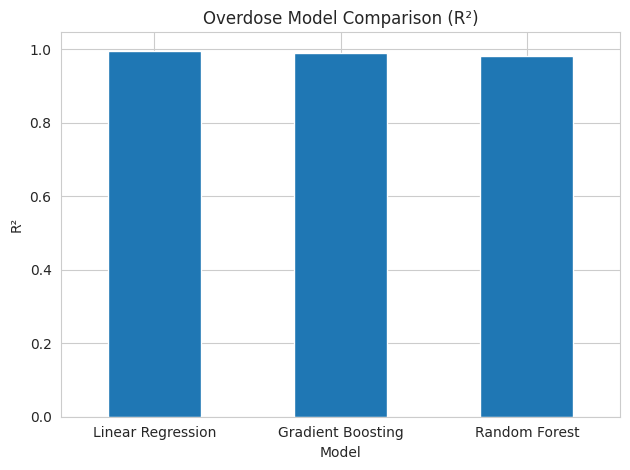

In [ ]:
import matplotlib.pyplot as plt
overdose_results.plot(x="Model", y="R2", kind="bar", legend=False, rot=0)
plt.title("Overdose Model Comparison (R²)")
plt.ylabel("R²")
plt.tight_layout()
plt.show()

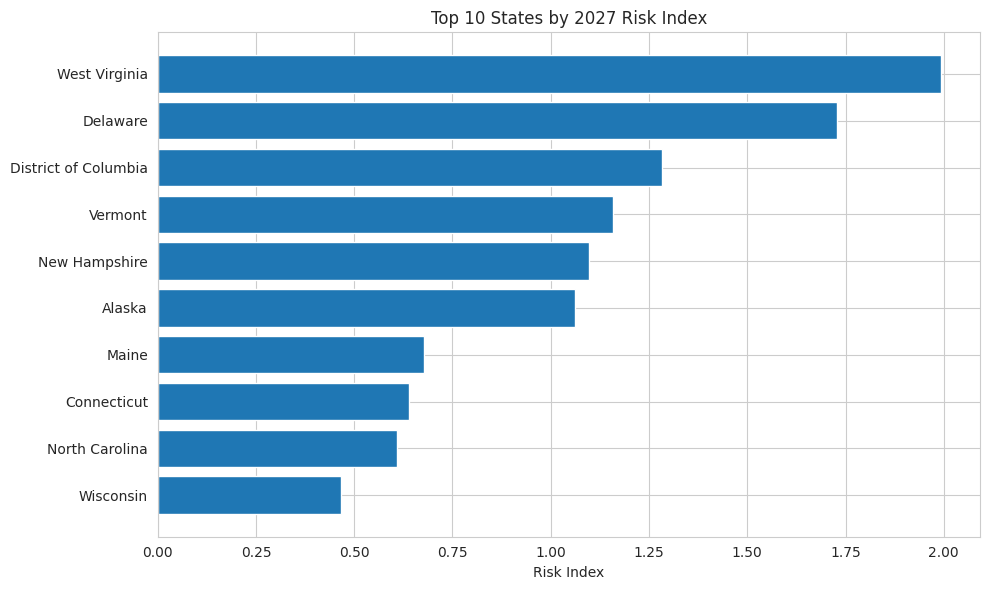

In [ ]:
import pandas as pd
top10 = risk_2027.head(10)

plt.figure(figsize=(10, 6))
plt.barh(top10["State"], top10["risk_index"])
plt.gca().invert_yaxis()
plt.title("Top 10 States by 2027 Risk Index")
plt.xlabel("Risk Index")
plt.tight_layout()
plt.show()

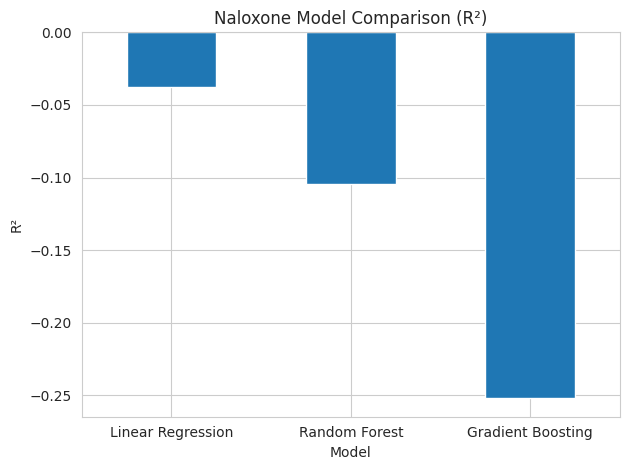

In [ ]:
naloxone_results.plot(x="Model", y="R2", kind="bar", legend=False, rot=0)
plt.title("Naloxone Model Comparison (R²)")
plt.ylabel("R²")
plt.tight_layout()
plt.show()

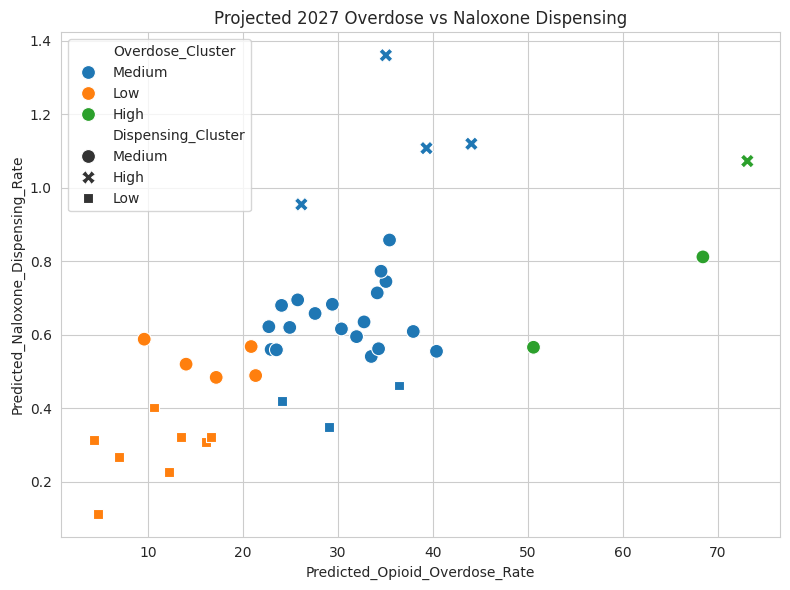

In [ ]:
proj_2027 = prediction_results[prediction_results["Year"] == 2027].copy()

plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=proj_2027,
    x="Predicted_Opioid_Overdose_Rate",
    y="Predicted_Naloxone_Dispensing_Rate",
    hue="Overdose_Cluster",
    style="Dispensing_Cluster",
    s=100
)
plt.title("Projected 2027 Overdose vs Naloxone Dispensing")
plt.tight_layout()
plt.show()

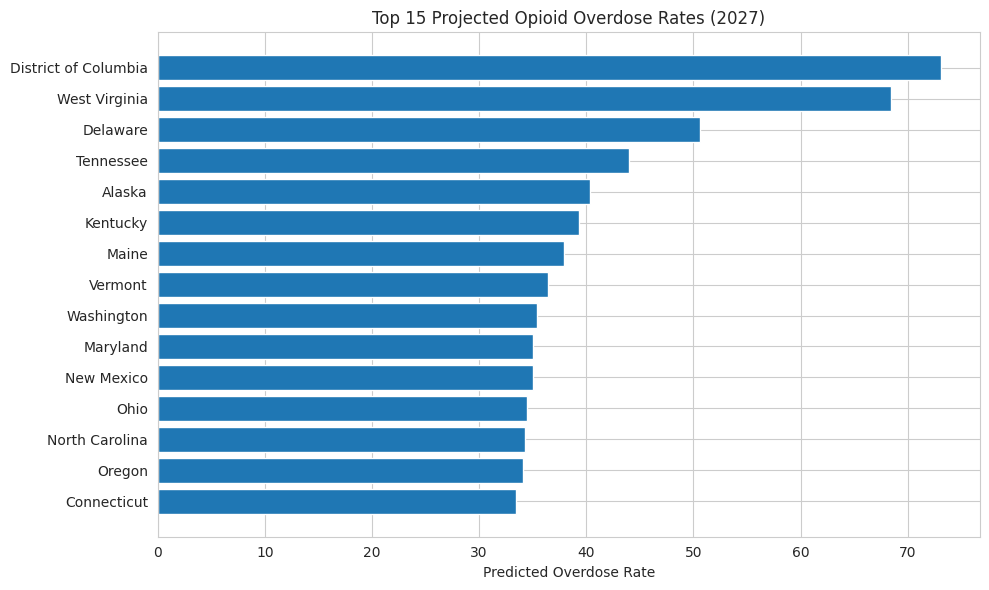

In [ ]:
top_overdose_2027 = (
    proj_2027.sort_values("Predicted_Opioid_Overdose_Rate", ascending=False)
    .head(15)
)

plt.figure(figsize=(10, 6))
plt.barh(
    top_overdose_2027["State"],
    top_overdose_2027["Predicted_Opioid_Overdose_Rate"]
)
plt.gca().invert_yaxis()
plt.title("Top 15 Projected Opioid Overdose Rates (2027)")
plt.xlabel("Predicted Overdose Rate")
plt.tight_layout()
plt.show()

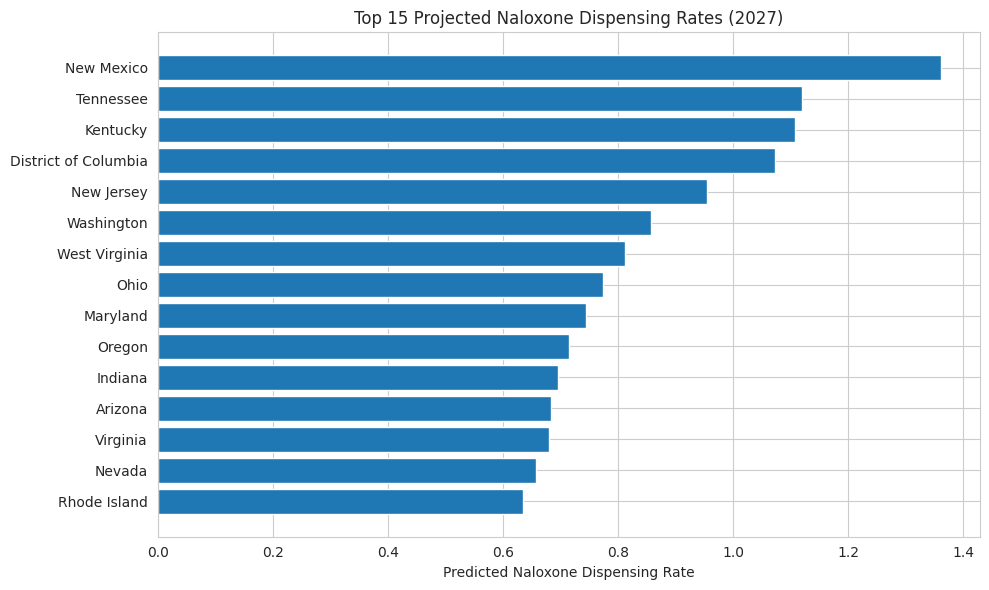

In [ ]:
top_naloxone_2027 = (
    proj_2027.sort_values("Predicted_Naloxone_Dispensing_Rate", ascending=False)
    .head(15)
)

plt.figure(figsize=(10, 6))
plt.barh(
    top_naloxone_2027["State"],
    top_naloxone_2027["Predicted_Naloxone_Dispensing_Rate"]
)
plt.gca().invert_yaxis()
plt.title("Top 15 Projected Naloxone Dispensing Rates (2027)")
plt.xlabel("Predicted Naloxone Dispensing Rate")
plt.tight_layout()
plt.show()

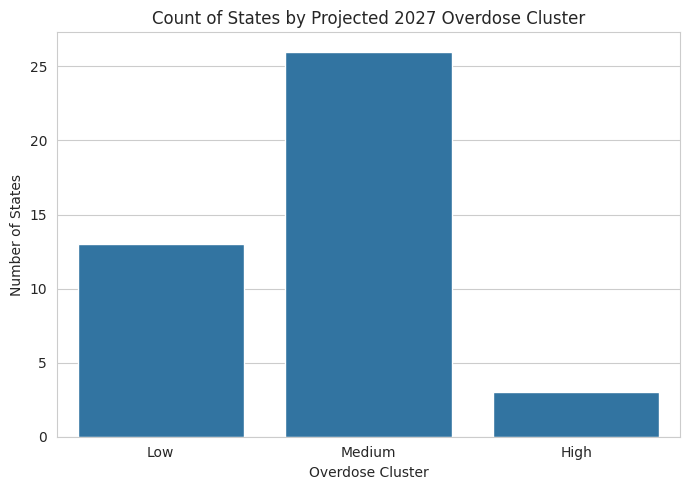

In [ ]:
plt.figure(figsize=(7, 5))
sns.countplot(data=proj_2027, x="Overdose_Cluster", order=["Low", "Medium", "High"])
plt.title("Count of States by Projected 2027 Overdose Cluster")
plt.xlabel("Overdose Cluster")
plt.ylabel("Number of States")
plt.tight_layout()
plt.show()

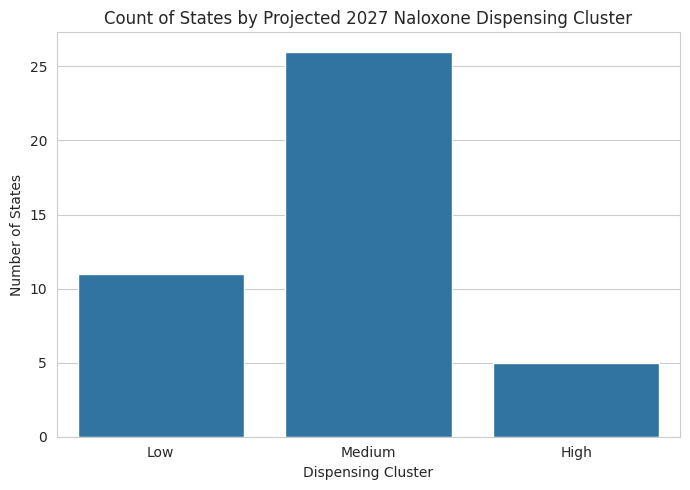

In [ ]:
plt.figure(figsize=(7, 5))
sns.countplot(data=proj_2027, x="Dispensing_Cluster", order=["Low", "Medium", "High"])
plt.title("Count of States by Projected 2027 Naloxone Dispensing Cluster")
plt.xlabel("Dispensing Cluster")
plt.ylabel("Number of States")
plt.tight_layout()
plt.show()

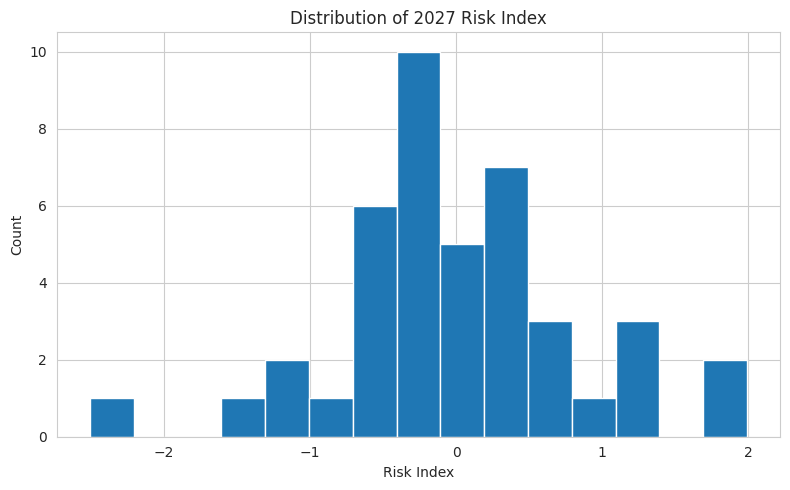

In [ ]:
plt.figure(figsize=(8, 5))
plt.hist(risk_2027["risk_index"], bins=15)
plt.title("Distribution of 2027 Risk Index")
plt.xlabel("Risk Index")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

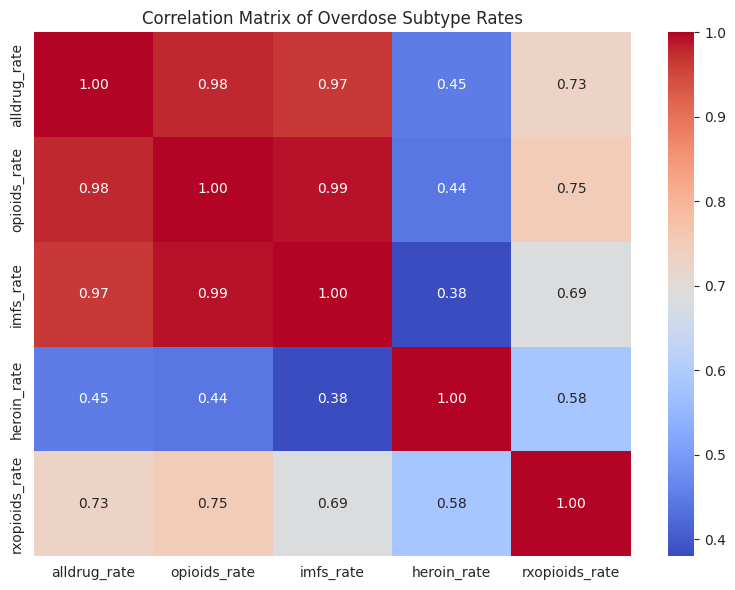

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

overdose_df = pd.read_excel("SUDORS-Fatal-Overdose-Data.xlsx", sheet_name="Data")

heatmap_cols = [
    "alldrug_rate",
    "opioids_rate",
    "imfs_rate",
    "heroin_rate",
    "rxopioids_rate"
]

heatmap_cols = [c for c in heatmap_cols if c in overdose_df.columns]

corr = overdose_df[heatmap_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix of Overdose Subtype Rates")
plt.tight_layout()
plt.show()